# Experiment 1 — Transformation Recovery

**Goal:** Given paired point clouds $P = T_1(S)$ and $Q = T_2(S)$ (both observed, matching known), fit
$$f(p) = Rp + t + u(p)$$
and check whether it recovers the ground-truth composed transformation $T_2 \circ T_1^{-1}$.
Compare with Rigid Transformation that does not have a residual field:
$$f(p) = Rp + t$$

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

from elastic_transformation import ElasticTransformation
from synthetic import SyntheticExperiment
from transformation import RigidTransformation
from utils import get_error_metrics
from visualization import ResidualVisualizer, TransformationVisualizer

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic data generation

- $S$: random point cloud (irregular, not a lattice)
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$  — matching is known ($p_i \leftrightarrow q_i$)
- Because $p_i = T_1(s_i)$ and $q_i = T_2(s_i)$, the ideal map (ignoring noise) is
$$f_{\mathrm{gt}}(p) = T_2 \circ T_1^{-1}(p)$$

In [2]:
exp = SyntheticExperiment.generate(n=2000, noise_std=3.0, t_scale=8.0, seed=42)
print(exp)

╭──────────────────────┬──────────────────────────────────────────────╮
│ Original Point Cloud │ PointCloud(n=2000)                           │
│ Transformation 1     │ RigidTransformation(rot=149.5°, t_norm=5.17) │
│ Transformation 2     │ RigidTransformation(rot=153.1°, t_norm=5.87) │
│ Point Cloud 1        │ PointCloud(n=2000)                           │
│ Point Cloud 2        │ PointCloud(n=2000)                           │
│ GT transformation    │ RigidTransformation(rot=16.3°, t_norm=8.98)  │
╰──────────────────────┴──────────────────────────────────────────────╯


## Fit transformations

Baseline: Fit a rigid-only transformation (no residual field) to establish a lower bound on residuals.
Elastic Transformation is fit on the same experiment.

Basic error metrics:
1. **Rotation error vs ground truth**: How much do the final transformation and the ground truth transformation differ in angle (deg)
2. **Translation error vs ground truth**: How much do the final transformation and the ground truth transformation differ in translation direction and distance
3. **Residuals**: The distance to the closest point across all points in the cloud - displayed is mean and max.

In [3]:
# Baseline: rigid-only fit (no residual field)
t0 = time.perf_counter()
rigid_fit = RigidTransformation.fit(exp.P, exp.Q)
t1 = time.perf_counter()
elastic_fit = ElasticTransformation.fit(
    exp.P, exp.Q,
    lambda1=0.1,
    lambda2=0.01,
    n_iter=200,
    lr=1e-2,
    k_neighbors=10,
    verbose=True,
)
t2 = time.perf_counter()
# get error metrics
rigid_rotation_error, rigid_translation_error, rigid_residuals = get_error_metrics(rigid_fit, exp.T_gt, exp.P, exp.Q)
elastic_rotation_error, elastic_translation_error, elastic_residuals = get_error_metrics(elastic_fit, exp.T_gt, exp.P, exp.Q)
# display them
rows = [
    ["Rotation error",      f"{rigid_rotation_error:.4f}°",   f"{elastic_rotation_error:.4f}°"],
    ["Translation error",   f"{rigid_translation_error:.4f}", f"{elastic_translation_error:.4f}"],
    ["Mean |u_i|",          "—",                              f"{np.linalg.norm(elastic_fit.u, axis=1).mean():.4f}"],
    ["Mean point residual", f"{rigid_residuals.mean():.4f}",  f"{elastic_residuals.mean():.4f}"],
    ["Max  point residual", f"{rigid_residuals.max():.4f}",   f"{elastic_residuals.max():.4f}"],
    ["Duration",            f"{t1 - t0:.2f} seconds",         f"{t2 - t1:.2f} seconds"],
]
print(tabulate(rows, headers=["Metric", "Rigid", "Elastic"], tablefmt="rounded_outline"))

ElasticFit: 100%|██████████| 200/200 [00:02<00:00, 80.33it/s, data=50.93412, loss=52.28039, reg=131.37919, u_mag=0.32486]


╭─────────────────────┬──────────────┬──────────────╮
│ Metric              │ Rigid        │ Elastic      │
├─────────────────────┼──────────────┼──────────────┤
│ Rotation error      │ 0.2441°      │ 0.2277°      │
│ Translation error   │ 0.3152       │ 0.2835       │
│ Mean |u_i|          │ —            │ 0.4739       │
│ Mean point residual │ 2.8160       │ 2.7459       │
│ Max  point residual │ 8.2007       │ 7.1471       │
│ Duration            │ 0.00 seconds │ 4.70 seconds │
╰─────────────────────┴──────────────┴──────────────╯


## 5. Visualisation

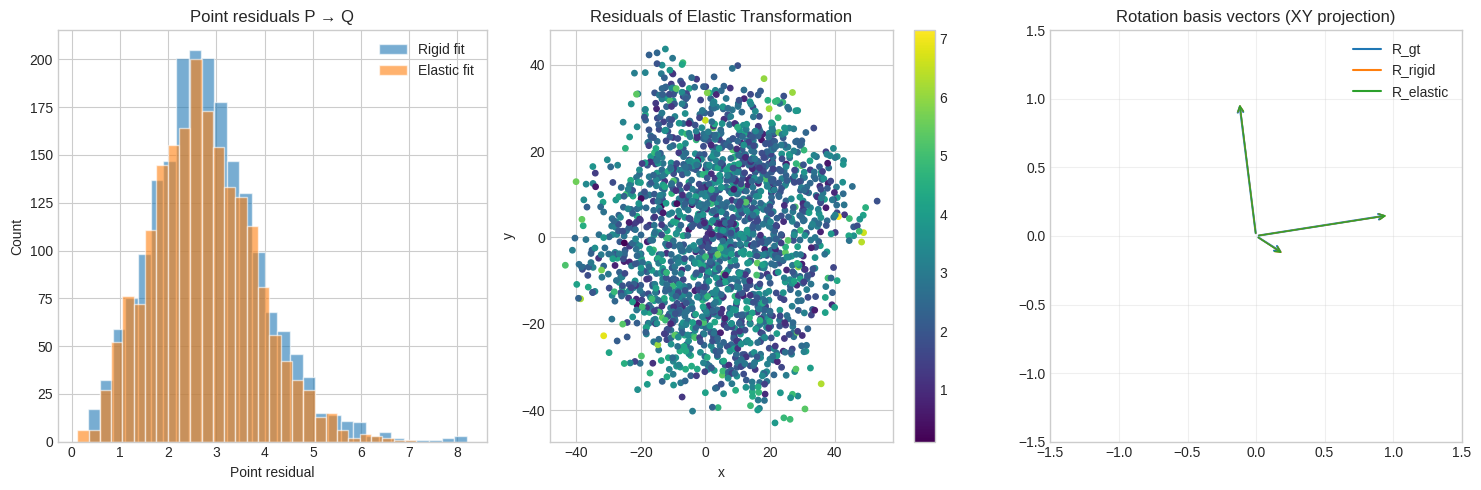

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ResidualVisualizer.plot_histogram(axes[0], [rigid_residuals, elastic_residuals], ['Rigid fit', 'Elastic fit'])
ResidualVisualizer.plot_field_heatmap(axes[1], exp.P.points, elastic_residuals)
TransformationVisualizer.plot_rotation_bases(axes[2], [exp.T_gt.R, rigid_fit.R, elastic_fit.R], ['R_gt', 'R_rigid', 'R_elastic'])

axes[1].set_title("Residuals of Elastic Transformation")

plt.tight_layout()
plt.savefig('../results/1_rigid_vs_elastic_transformation_results.png', dpi=150, bbox_inches='tight')
plt.show()